# ЛАБОРАТОРНА РОБОТА №5
## Побудова фракталів з використанням L-систем

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math
import cv2
import imageio
import numpy as np

### 1. Обрати 8 будь-яких фракталів та реалізувати їх
### 2. Спробувати змінити кут θ (angle) при побудові цих об’єктів. Отримати новий фрактальний об’єкт.

In [2]:
def build_fractal(axiom, rules, iteration):
    for _ in range(iteration):
        new_axiom = ''
        for char in axiom:
            if char in rules:
                new_axiom += rules[char]
            else:
                new_axiom += char
        axiom = new_axiom
    return axiom

In [3]:
def plot_fractal(axiom, dfi):
    
    fi = 0 
    x = [0]
    y = [0]
 
    for char in axiom:
        
        if char == 'F':
            x.append(x[-1] + math.cos(fi))
            y.append(y[-1] + math.sin(fi))
        elif char == '-':
            fi -= dfi
        elif char == '+':
            fi += dfi
    
    return x, y

In [4]:
def visualization_fractal(axiom, rules, dfi, iterations, color):
    
    results = []  

    for iteration in iterations:
        result = build_fractal(axiom, rules, iteration)
        x, y = plot_fractal(result, dfi)
        results.append((x, y))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (x, y) in enumerate(results):
        
        axes[i].plot(x, y, color = color)
        axes[i].set_title(f"Iteration = {iterations[i]}")
        axes[i].grid(True)

In [5]:
def angle_value_fractal(axiom, rules, dfi, iteration, color):
    
    result = build_fractal(axiom, rules, iteration)
    results = []  

    for fi in dfi:
        fi = math.radians(fi)
        x, y = plot_fractal(result, fi)
        results.append((x, y))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (x, y) in enumerate(results):
        axes[i].plot(x, y, color =  color)
        axes[i].set_title(f"fi = {dfi[i]}")
        axes[i].grid(True)

### Сніжинка Коха

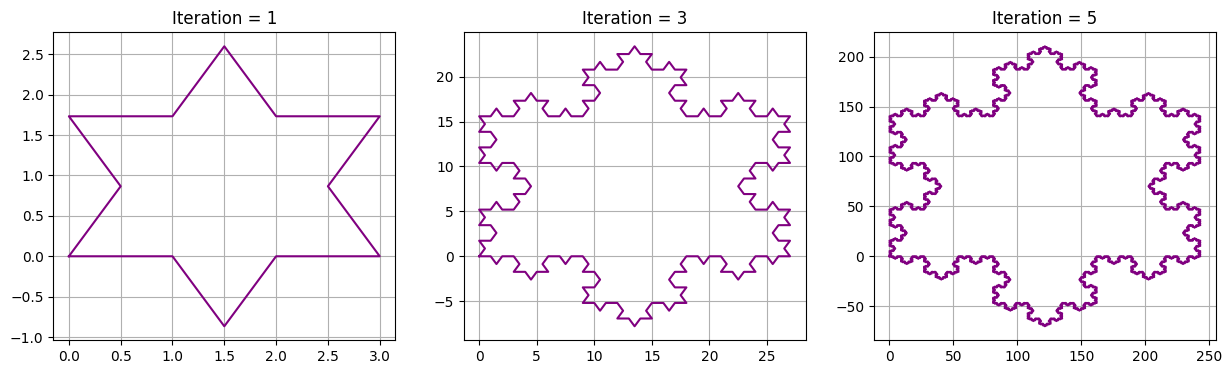

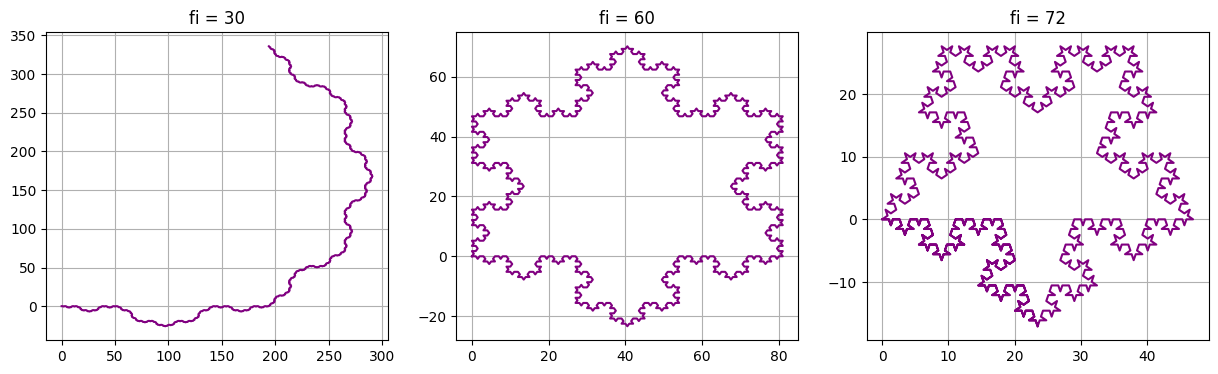

In [7]:
axiom = 'F++F++F'
rules = {'F': 'F-F++F-F'}
dfi = math.pi/3
iterations = [1, 3, 5]

visualization_fractal(axiom, rules, dfi, iterations, "purple")

dfi = [30, 60, 72]
iteration = 4

angle_value_fractal(axiom, rules, dfi, iteration, "purple")

### Закрита квадратна сніжинка

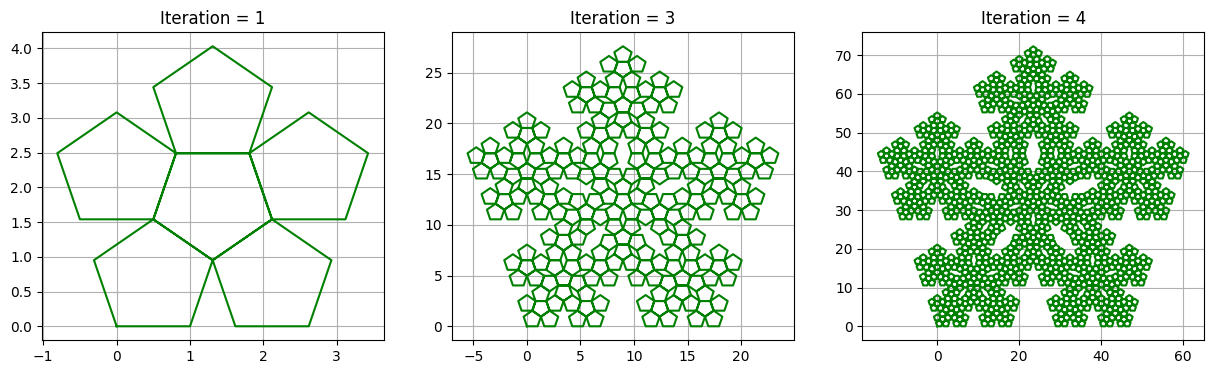

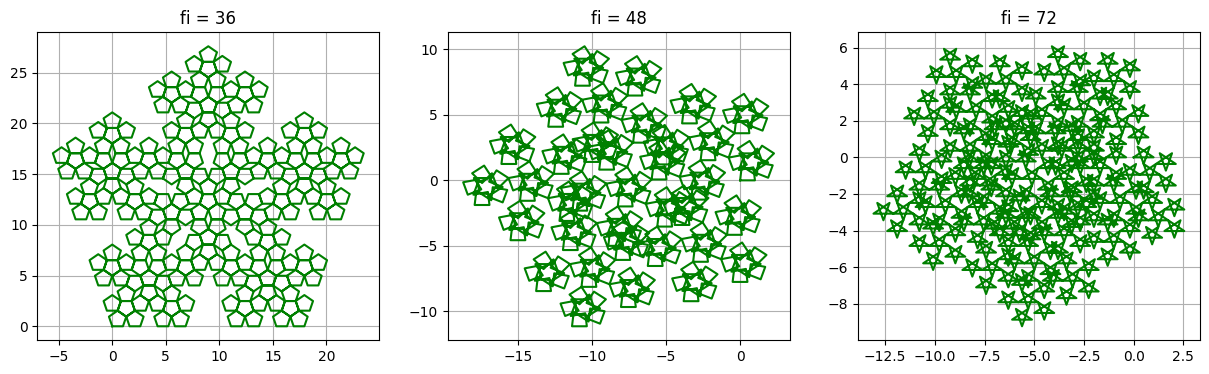

In [8]:
axiom = 'F++F++F++F++F'
rules = {'F': 'F++F++F+++++F-F++F'}
dfi = math.radians(36)
iterations = [1, 3, 4]

visualization_fractal(axiom, rules, dfi, iterations, "green")

dfi = [36, 48, 72]
iteration = 3

angle_value_fractal(axiom, rules, dfi, iteration, "green")

### Квадратний острівець Коха

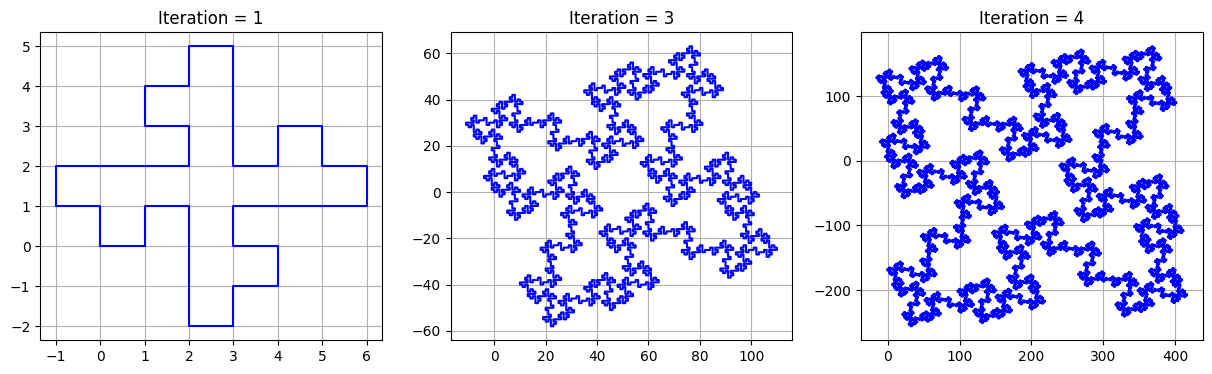

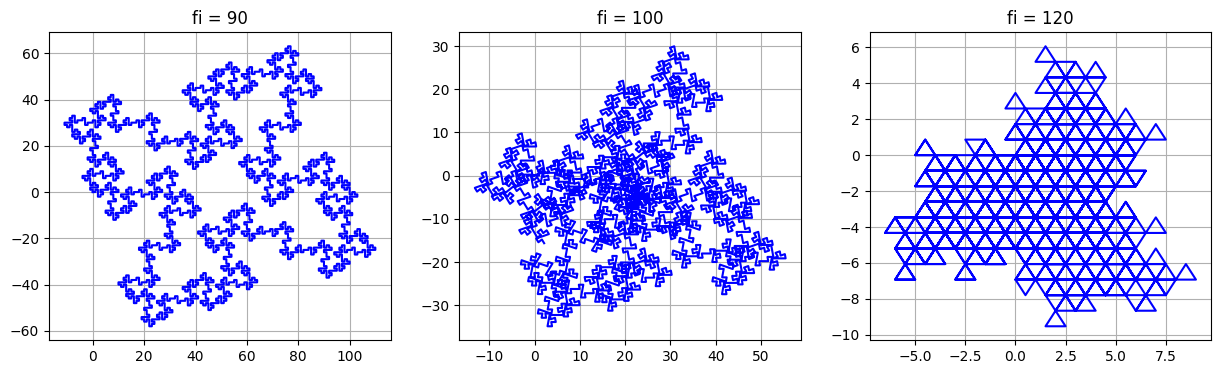

In [9]:
axiom = 'F+F+F+F'
rules = {'F': 'F+F-F-FFF+F+F-F'}
dfi = math.pi/2
iterations = [1, 3, 4]

visualization_fractal(axiom, rules, dfi, iterations, "blue")

dfi = [90, 100, 120]
iteration = 3

angle_value_fractal(axiom, rules, dfi, iteration, "blue")

### Хрестоподібний фрактал

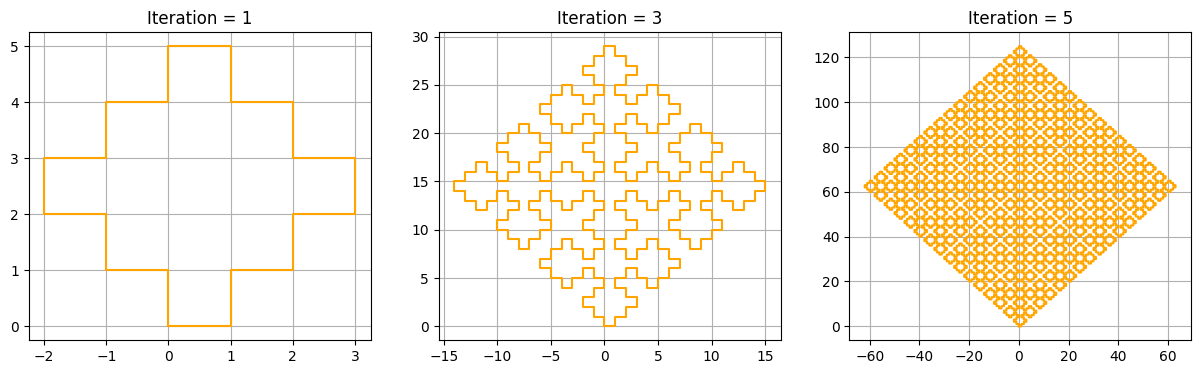

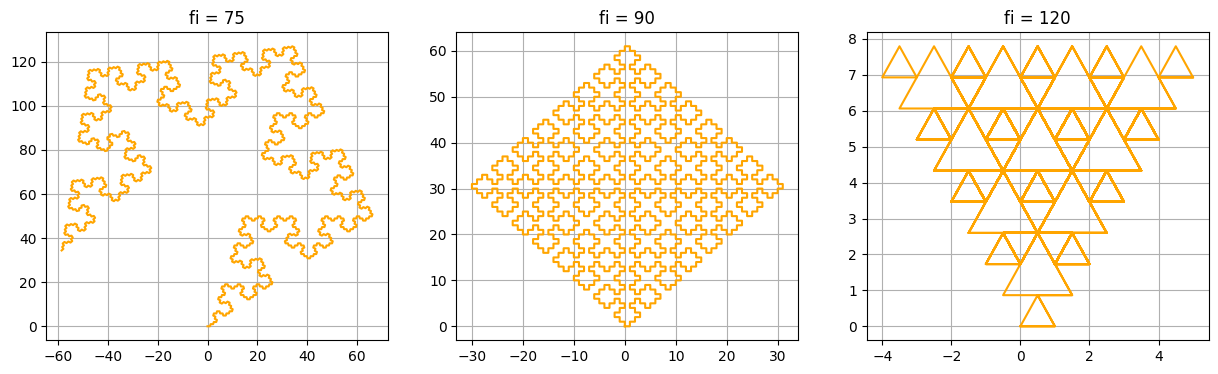

In [10]:
axiom = 'F+XF+F+XF'
rules = {'X': 'XF-F+F-XF+F+XF-F+F-X'}
dfi = math.pi/2
iterations = [1, 3, 5]

visualization_fractal(axiom, rules, dfi, iterations, "orange")

dfi = [75, 90, 120]
iteration = 4

angle_value_fractal(axiom, rules, dfi, iteration, "orange")

### Фрактальна крива Пеано

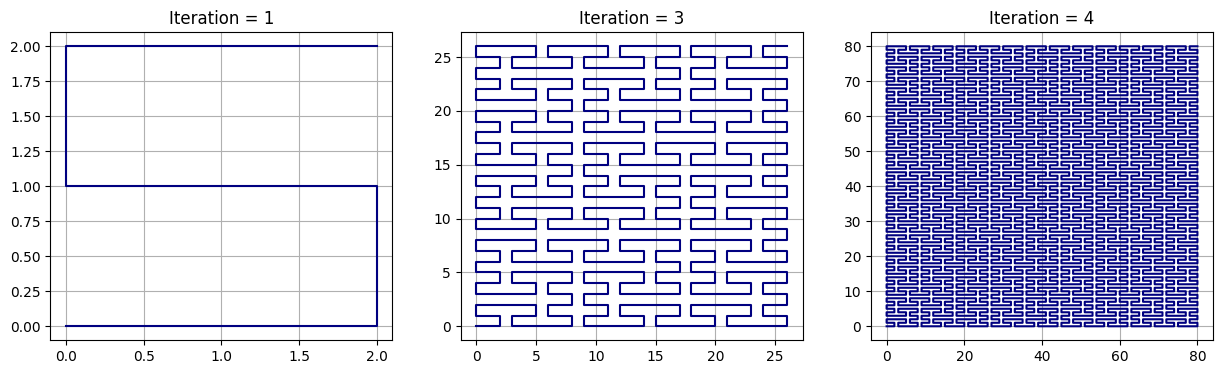

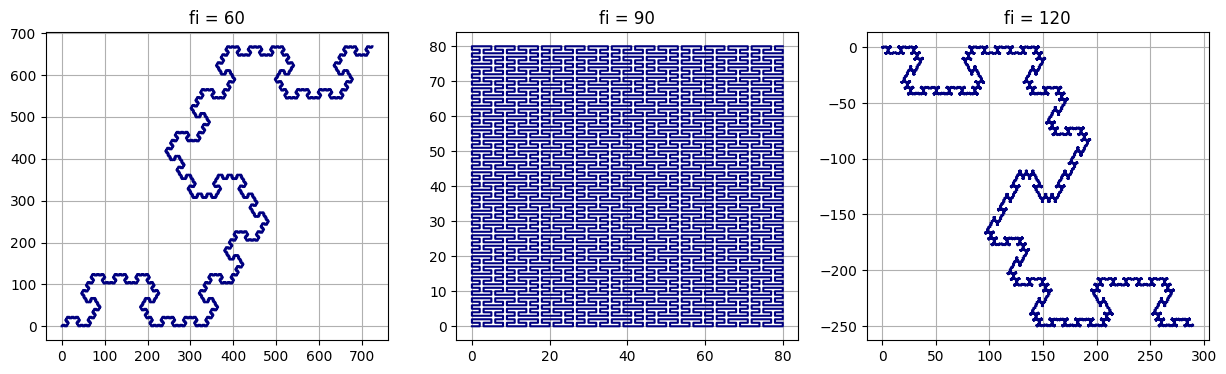

In [12]:
axiom = 'X'
rules = {'X': 'XFYFX+F+YFXFY-F-XFYFX',
         'Y': 'YFXFY-F-XFYFX+F+YFXFY'}
dfi = math.pi/2
iterations = [1, 3, 4]

visualization_fractal(axiom, rules, dfi, iterations, "navy")

dfi = [60, 90, 120]
iteration = 4

angle_value_fractal(axiom, rules, dfi, iteration, "navy")

### Крива дракона

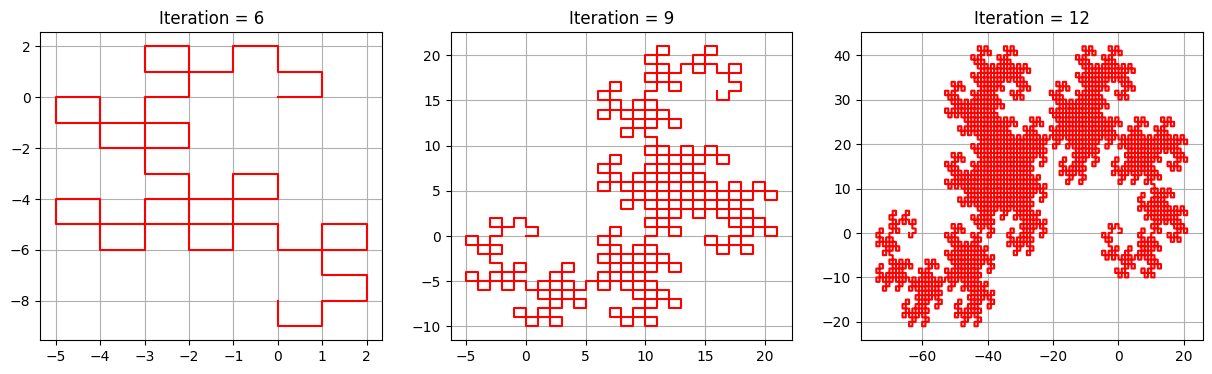

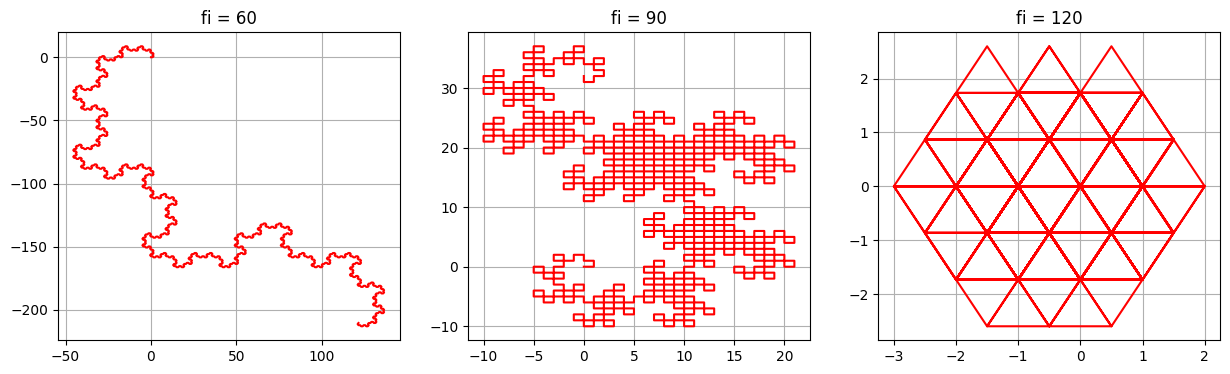

In [13]:
axiom = 'FX'
rules = {'X': 'X+YF+',
         'Y': '-FX-Y'}
dfi = math.pi/2
iterations = [6, 9, 12]

visualization_fractal(axiom, rules, dfi, iterations, "red")

dfi = [60, 90, 120]
iteration = 10

angle_value_fractal(axiom, rules, dfi, iteration, "red")

### Гексагональна крива Госпера

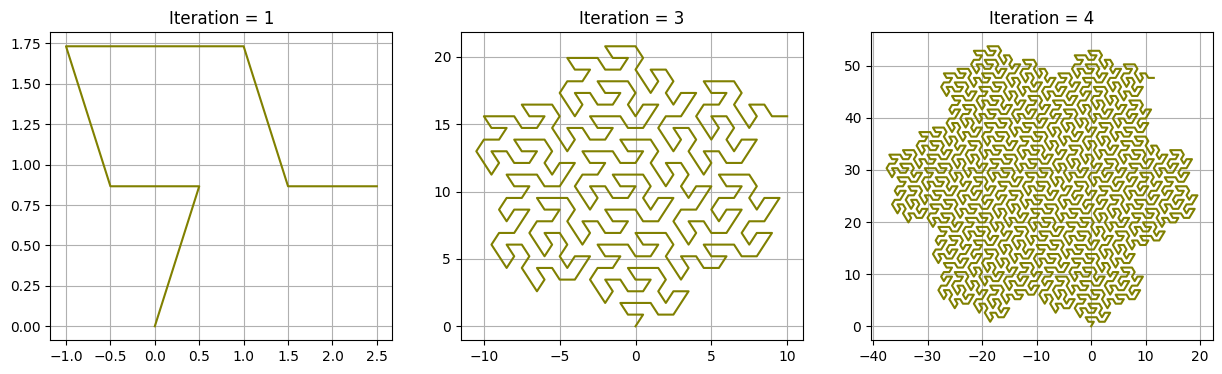

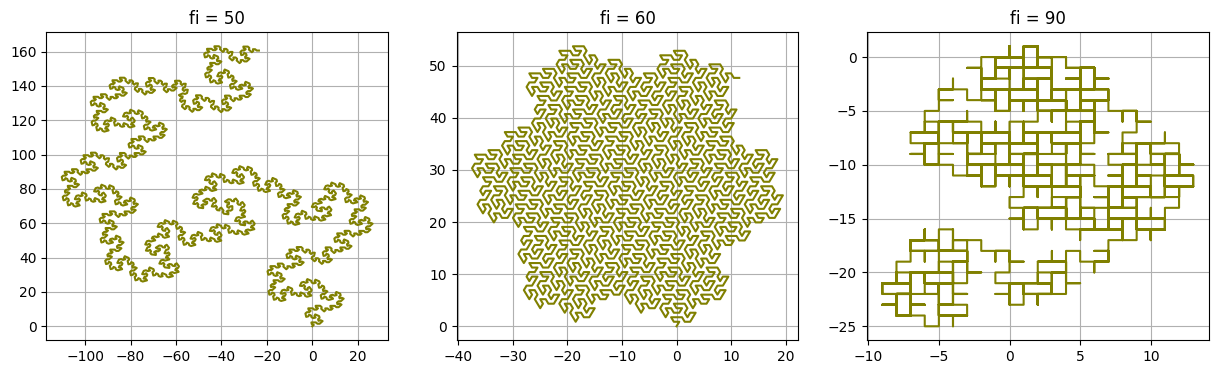

In [24]:
axiom = 'XF'
rules = {'X': 'X+YF++YF-FX--FXFX-YF+',
         'Y': '-FX+YFYF++YF+FX--FX-Y'}
dfi = math.pi/3
iterations = [1, 3, 4]

visualization_fractal(axiom, rules, dfi, iterations, "olive")

dfi = [50, 60, 90]
iteration = 4

angle_value_fractal(axiom, rules, dfi, iteration, "olive")

### Наконечник стріли Серпінського

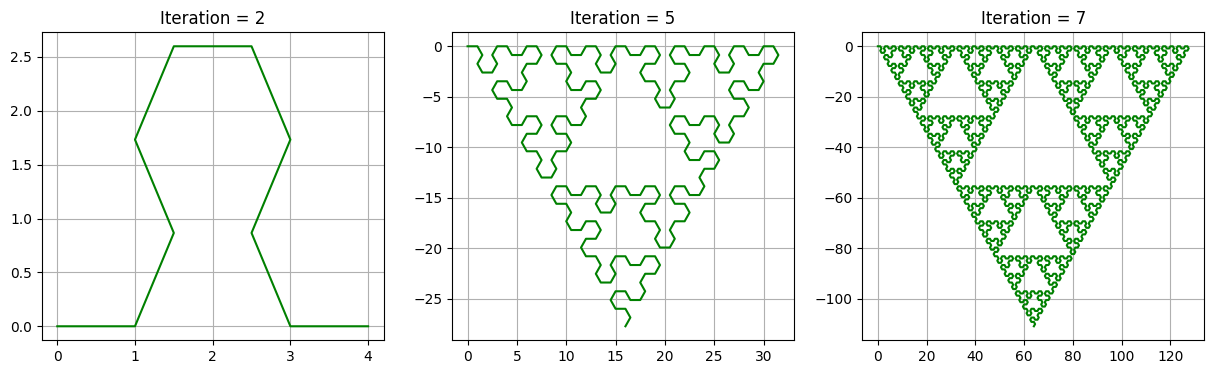

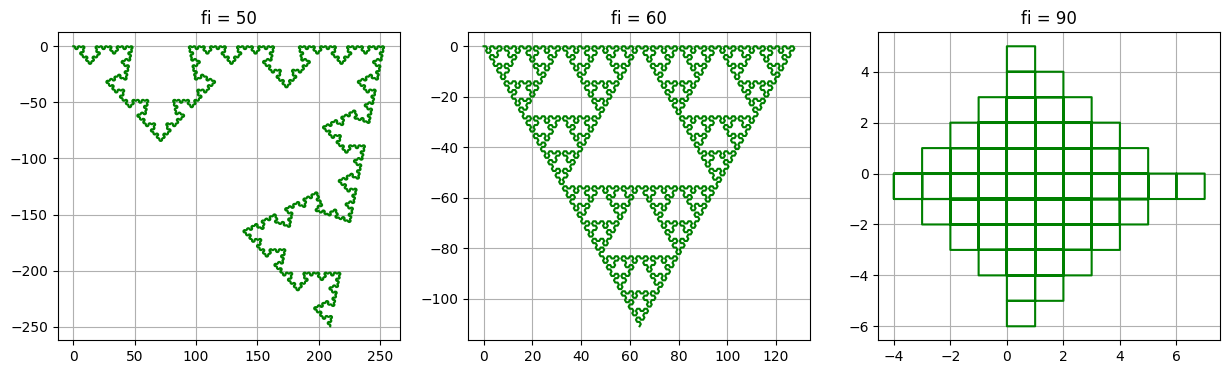

In [20]:
axiom = 'YF'
rules = {'X': 'YF+XF+Y',
         'Y': 'XF-YF-X'}
dfi = math.pi/3
iterations = [2, 5, 7]

visualization_fractal(axiom, rules, dfi, iterations, "green")

dfi = [50, 60, 90]
iteration = 7

angle_value_fractal(axiom, rules, dfi, iteration, "green")

### 3. Модифікувати програму для побудови фракталів з кутом θmin ≤ θ ≤ θmax. Зробити відображення у вигляді плавного переходу для вказаного діапазону θ ∈ [θmin; θmax].

In [37]:
def fractal_animation(axiom, rules, iterations):
    
    result = build_fractal(axiom, rules, iterations)

    step = 0.005
    frames = int(1 / step)
    fi_values = np.linspace(1, 360, frames)

    img_h, img_w = 600, 600
    animation = np.zeros((img_h, img_w, 3, frames), dtype=np.uint8)

    for k in range(frames):
    
        fi = fi_values[k]
        fi = math.radians(fi)
        x, y = plot_fractal(result, fi)
 
        x = np.array(x)
        y = np.array(y)
        x = (x - x.min()) / (x.max() - x.min()) * (img_w - 1)
        y = (y - y.min()) / (y.max() - y.min()) * (img_h - 1)
        y = img_h - 1 - y  

        img = np.ones((img_h, img_w, 3), dtype=np.uint8) * 255
   
        for i in range(1, len(x)):
            point_1 = (int(x[i-1]), int(y[i-1]))
            point_2 = (int(x[i]), int(y[i]))
            cv2.line(img, point_1, point_2, (0, 0, 0), 1, lineType=cv2.LINE_AA)
    
        animation[:, :, :, k] = img

    for k in range(frames):
        frame = animation[:, :, :, k]
        cv2.imshow("Fractal", frame)
        if cv2.waitKey(150) & 0xFF == ord('q'):
            break

    cv2.destroyAllWindows()

In [ ]:
axiom = 'F++F++F'
rules = {'F': 'F-F++F-F'}
fractal_animation(axiom, rules, 4)

In [39]:
axiom = 'F+XF+F+XF'
rules = {'X': 'XF-F+F-XF+F+XF-F+F-X'}
fractal_animation(axiom, rules, 4)

In [41]:
axiom = 'XF'
rules = {'X': 'X+YF++YF-FX--FXFX-YF+',
         'Y': '-FX+YFYF++YF+FX--FX-Y'}
fractal_animation(axiom, rules, 4)

In [43]:
axiom = 'X'
rules = {'X': 'XFYFX+F+YFXFY-F-XFYFX',
         'Y': 'YFXFY-F-XFYFX+F+YFXFY'}
fractal_animation(axiom, rules, 3)